In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("AirPassengers.csv",parse_dates=["Month"],index_col="Month")

In [3]:
df.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [4]:
df=df.asfreq("MS")

In [5]:
df.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [6]:
df.rename(columns={"#Passengers":"Passengers"},inplace=True)

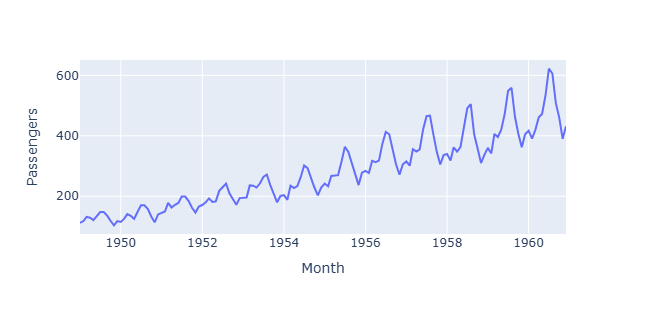

In [7]:
#Using Plotly Express
fig=px.line(
    df,
    x=df.index,
    y=df["Passengers"],
    labels={"Month":"Month","Passengers":"Passengers"}
)
fig.update_layout(
    width=1000,
    height=300
)
fig.show()

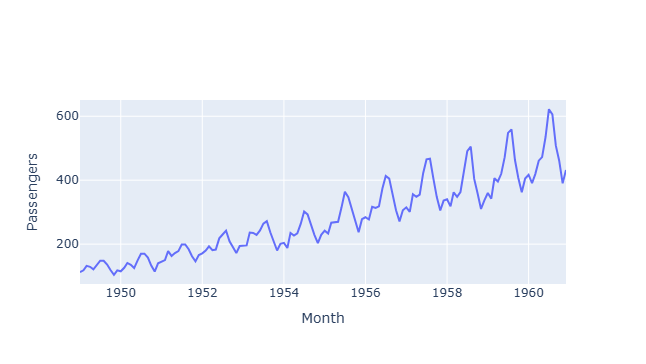

In [8]:
# Using Graph Objects
import plotly.graph_objects as go 
fig=go.Figure()
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["Passengers"],
        mode="lines",
        name="Passengers"
    ))
fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Passengers",
    width=1000,
    height=350)
fig.show()

In [9]:
monthly_avg=df.groupby(df.index.month)["Passengers"].mean()
month_names=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

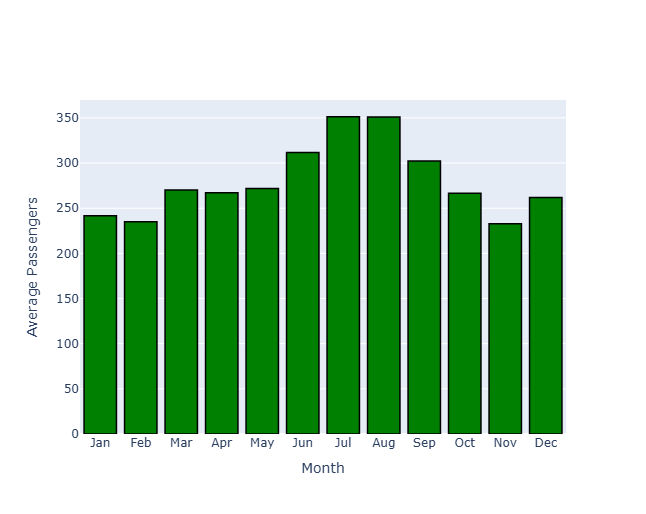

In [10]:
import plotly.graph_objects as go
fig=go.Figure()
fig.add_trace(go.Bar(
    x=month_names,
    y=monthly_avg.values,
    marker_color="green",
    marker_line_color="black",
    marker_line_width=1.5))
fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Average Passengers",
    width=1000,
    height=500
)
fig.show()

In [15]:
df["log_passengers"]=np.log(df["Passengers"])

In [79]:
df=df.drop(columns=["log_passgengers"])

In [80]:
df

,Passengers,log_passengers,log_diff,log_seasonal_diff
Month,,,,
1949-01-01,112,4.718499,NaN,NaN
1949-02-01,118,4.770685,0.052186,NaN
1949-03-01,132,4.882802,0.112117,NaN
1949-04-01,129,4.859812,-0.022990,NaN
1949-05-01,121,4.795791,-0.064022,NaN
...,...,...,...,...
1960-08-01,606,6.406880,-0.026060,-0.045934
1960-09-01,508,6.230481,-0.176399,0.012024
1960-10-01,461,6.133398,-0.097083,0.031830


In [17]:
from statsmodels.tsa.stattools import adfuller
res=adfuller(df["log_passengers"].dropna())
print("P value:",res[1])

P value: 0.42236677477039125


In [21]:
df["log_diff"]=df["log_passengers"].diff()

In [22]:
result=adfuller(df["log_diff"].dropna())
print("P-value:",result[1])

P-value: 0.07112054815085875


In [26]:
from statsmodels.graphics.tsaplots import plot_pacf,plot_acf

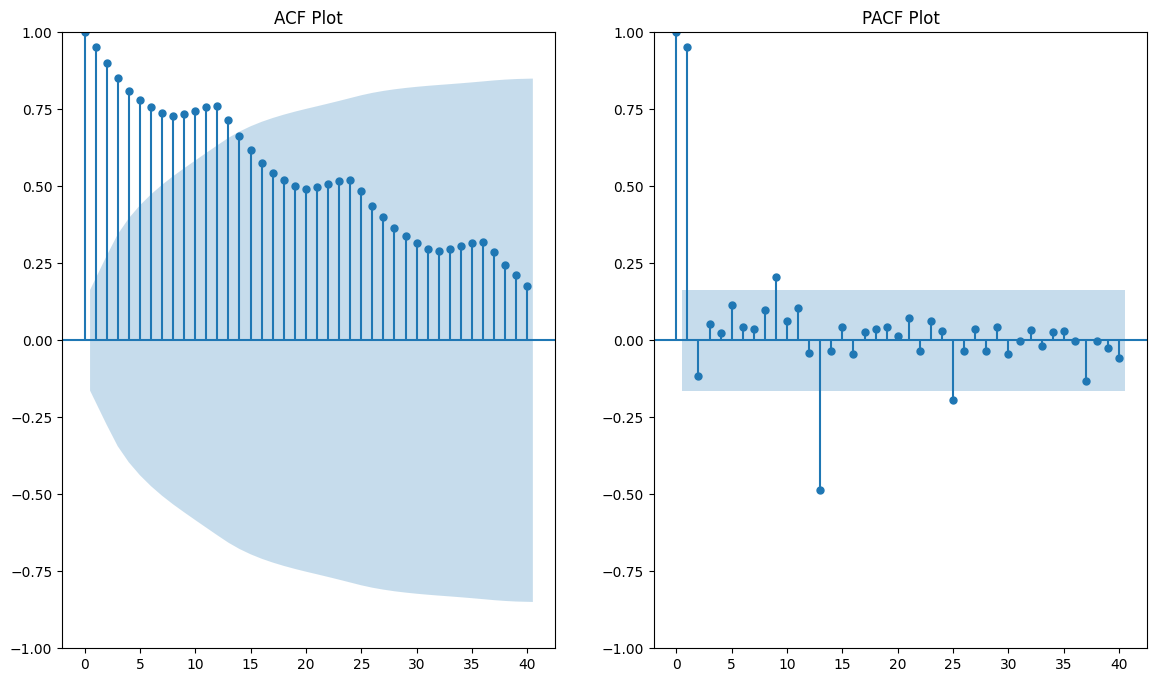

In [28]:
fig,axes=plt.subplots(1,2,figsize=(14,8))
plot_acf(df["log_passengers"],lags=40,ax=axes[0])
axes[0].set_title("ACF Plot")
plot_pacf(df["log_passengers"],lags=40,ax=axes[1])
axes[1].set_title("PACF Plot")
plt.show()

In [34]:
#Training Data-1949-1954
#Testing data-1955-1960
train=df.loc["1949":"1954"]
test=df.loc["1955":"1960"]
train_log = np.log(train["Passengers"])
test_log  = np.log(test["Passengers"])

In [35]:
# Arima Model
from statsmodels.tsa.arima.model import ARIMA

In [45]:
model=ARIMA(train["log_passengers"],order=(1,1,1))
model_arima=model.fit()
print(model_arima.summary())

                               SARIMAX Results                                
Dep. Variable:         log_passengers   No. Observations:                   72
Model:                 ARIMA(1, 1, 1)   Log Likelihood                  62.440
Date:                Tue, 03 Mar 2026   AIC                           -118.880
Time:                        13:18:48   BIC                           -112.092
Sample:                    01-01-1949   HQIC                          -116.181
                         - 12-01-1954                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6567      0.293     -2.243      0.025      -1.230      -0.083
ma.L1          0.8364      0.190      4.413      0.000       0.465       1.208
sigma2         0.0101      0.002      4.394      0.0

In [47]:
forecast_log=model_arima.forecast(steps=len(test))
arima_forecast=np.exp(forecast_log)
print(arima_forecast)

1955-01-01    234.410907
1955-02-01    230.843592
1955-03-01    233.179907
1955-04-01    231.643108
1955-05-01    232.651106
                 ...    
1960-08-01    232.251039
1960-09-01    232.251039
1960-10-01    232.251039
1960-11-01    232.251039
1960-12-01    232.251039
Freq: MS, Name: predicted_mean, Length: 72, dtype: float64


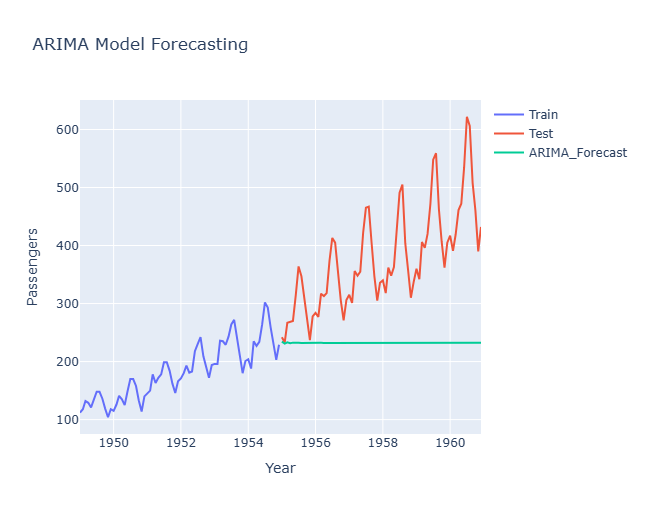

In [48]:
## Ploting arima
fig=go.Figure()
fig.add_trace(go.Scatter(
    x=train.index,
    y=train["Passengers"],
    mode="lines",
    name="Train"))
fig.add_trace(go.Scatter(
    x=test.index,
    y=test["Passengers"],
    mode="lines",
    name="Test"))
fig.add_trace(go.Scatter(
    x=test.index,
    y=arima_forecast,
    mode="lines",
    name="ARIMA_Forecast"))
fig.update_layout(
    title="ARIMA Model Forecasting",
    xaxis_title="Year",
    yaxis_title="Passengers",
    width=1000,
    height=500)
fig.show()

In [49]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train_log,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit()

print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                   72
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                  75.234
Date:                            Tue, 03 Mar 2026   AIC                           -140.468
Time:                                    13:21:14   BIC                           -131.435
Sample:                                01-01-1949   HQIC                          -137.101
                                     - 12-01-1954                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0815      0.354      0.231      0.818      -0.611       0.774
ma.L1         -0.5930      0.291   

In [50]:
forecast_log = sarima_fit.forecast(steps=len(test))
sarima_forecast = np.exp(forecast_log)

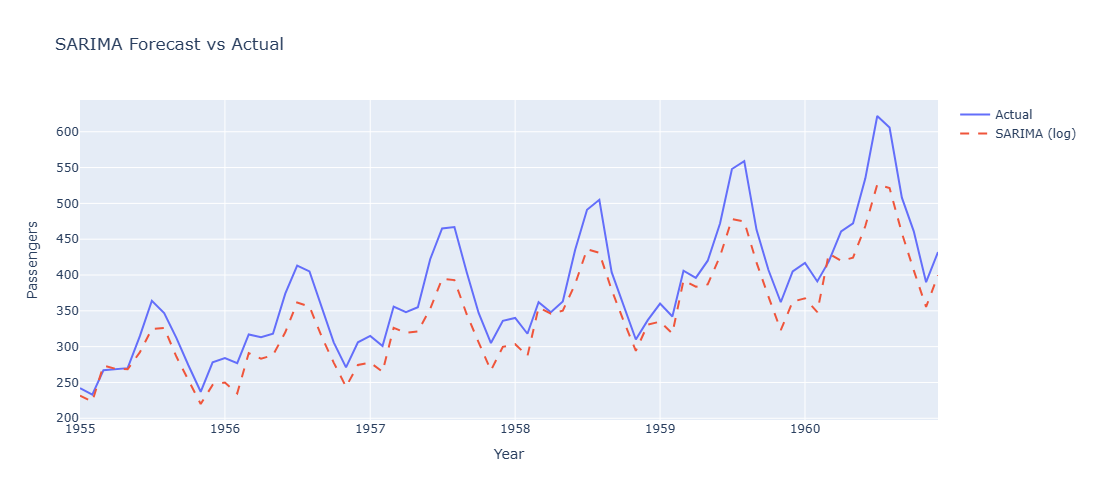

In [52]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=test.index,
    y=test["Passengers"],
    mode="lines",
    name="Actual"
))
fig.add_trace(go.Scatter(
    x=test.index,
    y=sarima_forecast,
    mode="lines",
    name="SARIMA (log)",
    line=dict(dash="dash")
))
fig.update_layout(
    title="SARIMA Forecast vs Actual",
    xaxis_title="Year",
    yaxis_title="Passengers",
    width=1000,
    height=500
)
fig.show()

In [55]:
from prophet import Prophet

train_prophet = train[["Passengers"]].reset_index()
train_prophet.columns = ["ds", "y"]

In [56]:
df.head()

,Passengers,log_passgengers,log_passengers,log_diff,log_seasonal_diff
Month,,,,,
1949-01-01,112,4.718499,4.718499,NaN,NaN
1949-02-01,118,4.770685,4.770685,0.052186,NaN
1949-03-01,132,4.882802,4.882802,0.112117,NaN
1949-04-01,129,4.859812,4.859812,-0.022990,NaN
1949-05-01,121,4.795791,4.795791,-0.064022,NaN


In [57]:
prophet_model=Prophet(
    seasonality_mode='multiplicative',  
    yearly_seasonality=True,
    weekly_seasonality=False,    
    daily_seasonality=False,     
    changepoint_prior_scale=0.05,  
    seasonality_prior_scale=10     
)

In [59]:
prophet_model.fit(train_prophet)

13:27:33 - cmdstanpy - INFO - Chain [1] start processing
13:27:34 - cmdstanpy - INFO - Chain [1] done processing


In [60]:
future = prophet_model.make_future_dataframe(periods=len(test), freq="MS")
prophet_forecast = prophet_model.predict(future)

In [61]:
forecast_test = prophet_forecast.tail(len(test))

In [62]:
forecast_test

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yearly,yearly_lower,yearly_upper,additive_terms,additive_terms_lower,additive_terms_upper,yhat
72,1955-01-01,253.077004,220.674645,236.930568,253.053957,253.090568,-0.096636,-0.096636,-0.096636,-0.096636,-0.096636,-0.096636,0.0,0.0,0.0,228.620697
73,1955-02-01,254.768885,223.194989,240.190957,254.684382,254.830580,-0.091573,-0.091573,-0.091573,-0.091573,-0.091573,-0.091573,0.0,0.0,0.0,231.438829
74,1955-03-01,256.297035,258.924612,275.779239,256.118212,256.447006,0.041894,0.041894,0.041894,0.041894,0.041894,0.041894,0.0,0.0,0.0,267.034303
75,1955-04-01,257.988916,245.305011,261.131429,257.697515,258.242142,-0.019095,-0.019095,-0.019095,-0.019095,-0.019095,-0.019095,0.0,0.0,0.0,253.062672
76,1955-05-01,259.626220,252.026478,267.899846,259.185791,259.981201,0.001158,0.001158,0.001158,0.001158,0.001158,0.001158,0.0,0.0,0.0,259.926944
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,1960-08-01,364.359089,405.594142,471.556763,337.592624,389.432051,0.205812,0.205812,0.205812,0.205812,0.205812,0.205812,0.0,0.0,0.0,439.348637
140,1960-09-01,366.050970,346.972167,405.427754,338.516110,391.694110,0.030753,0.030753,0.030753,0.030753,0.030753,0.030753,0.0,0.0,0.0,377.308008
141,1960-10-01,367.688274,312.376613,365.547186,339.593467,393.757669,-0.075322,-0.075322,-0.075322,-0.075322,-0.075322,-0.075322,0.0,0.0,0.0,339.993147
142,1960-11-01,369.380155,273.964896,320.155735,340.689658,395.925264,-0.193087,-0.193087,-0.193087,-0.193087,-0.193087,-0.193087,0.0,0.0,0.0,298.057546


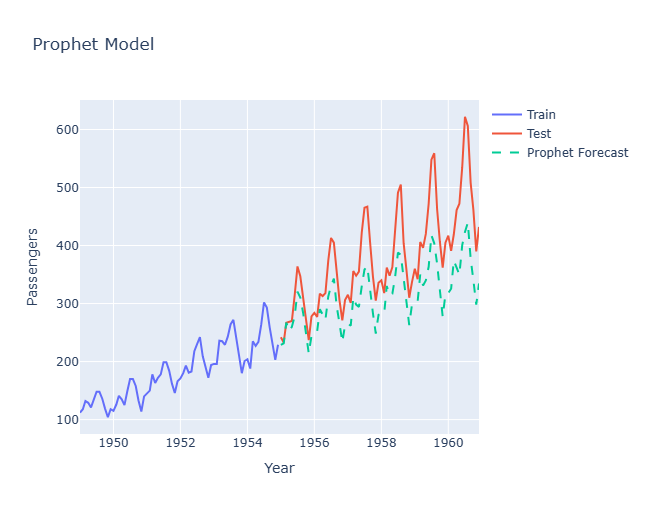

In [63]:
fig=go.Figure()
fig.add_trace(go.Scatter(
    x=train.index,
    y=train["Passengers"],
    mode="lines",
    name="Train"))
fig.add_trace(go.Scatter(
    x=test.index,
    y=test["Passengers"],
    mode="lines",
    name="Test"
))
fig.add_trace(go.Scatter(
    x=forecast_test["ds"],
    y=forecast_test["yhat"],
    mode="lines",
    name="Prophet Forecast",
    line=dict(dash="dash"))
             )
fig.update_layout(title="Prophet Model",
                  xaxis_title="Year",
                  yaxis_title="Passengers",
                  width=1000,
                  height=500)
fig.show()

In [64]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [81]:
hw_model = ExponentialSmoothing(
    train_log,
    trend="add",
    seasonal="add",   
    seasonal_periods=12
)
hw_fit = hw_model.fit()
forecast_log = hw_fit.forecast(len(test))
hw_forecast = np.exp(forecast_log)

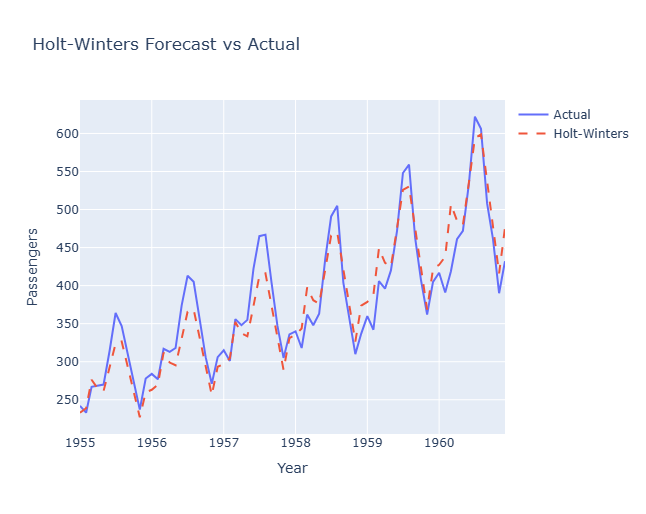

In [66]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=test.index,
    y=test["Passengers"],
    mode="lines",
    name="Actual"
))

fig.add_trace(go.Scatter(
    x=test.index,
    y=hw_forecast,
    mode="lines",
    name="Holt-Winters",
    line=dict(dash="dash")
))

fig.update_layout(
    title="Holt-Winters Forecast vs Actual",
    xaxis_title="Year",
    yaxis_title="Passengers",
    width=1000,
    height=500
)

fig.show()

In [67]:
from statsmodels.tsa.exponential_smoothing.ets import ETSModel

In [82]:
ets_model = ETSModel(
    train_log,
    error="add",
    trend="add",
    seasonal="add",   
    seasonal_periods=12
)
ets_fit = ets_model.fit()
forecast_log = ets_fit.forecast(steps=len(test))
ets_forecast = np.exp(forecast_log)

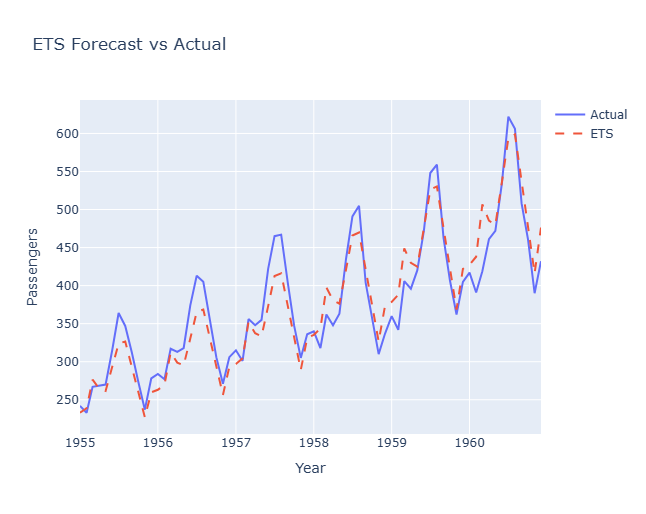

In [69]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=test.index,
    y=test["Passengers"],
    mode="lines",
    name="Actual"
))

fig.add_trace(go.Scatter(
    x=test.index,
    y=ets_forecast,
    mode="lines",
    name="ETS",
    line=dict(dash="dash")
))

fig.update_layout(
    title="ETS Forecast vs Actual",
    xaxis_title="Year",
    yaxis_title="Passengers",
    width=1000,
    height=500
)

fig.show()

In [70]:
comparison_df = pd.DataFrame({
    "Actual": test["Passengers"].values,
    "ARIMA": arima_forecast,
    "SARIMA": sarima_forecast,
    "Prophet": forecast_test["yhat"].values,
    "Holt_Winters": hw_forecast,
    "ETS": ets_forecast
}, index=test.index)

comparison_df.head()

,Actual,ARIMA,SARIMA,Prophet,Holt_Winters,ETS
Month,,,,,,
1955-01-01,242,234.410907,231.500618,228.620697,233.094516,233.093993
1955-02-01,233,230.843592,223.411992,231.438829,238.877973,238.877468
1955-03-01,267,233.179907,273.563457,267.034303,276.352104,276.351819
1955-04-01,269,231.643108,268.959809,253.062672,264.738955,264.738766
1955-05-01,270,232.651106,268.455898,259.926944,261.592560,261.591927


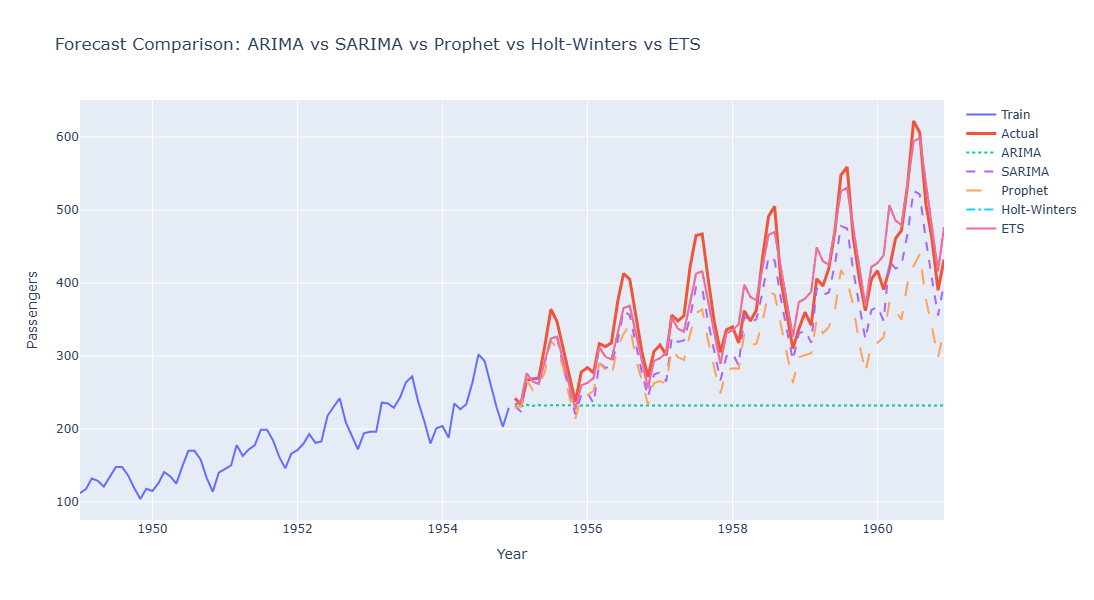

In [75]:
import plotly.graph_objects as go
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=train.index,
    y=train["Passengers"],
    mode="lines",
    name="Train",
    line=dict(width=2)
))
fig.add_trace(go.Scatter(
    x=test.index,
    y=test["Passengers"],
    mode="lines",
    name="Actual",
    line=dict(width=3)
))
fig.add_trace(go.Scatter(
    x=test.index,
    y=arima_forecast,
    mode="lines",
    name="ARIMA",
    line=dict(dash="dot")
))
fig.add_trace(go.Scatter(
    x=test.index,
    y=sarima_forecast,
    mode="lines",
    name="SARIMA",
    line=dict(dash="dash")
))
fig.add_trace(go.Scatter(
    x=test.index,
    y=forecast_test["yhat"],
    mode="lines",
    name="Prophet",
    line=dict(dash="longdash")
))
fig.add_trace(go.Scatter(
    x=test.index,
    y=hw_forecast,
    mode="lines",
    name="Holt-Winters",
    line=dict(dash="dashdot")
))
fig.add_trace(go.Scatter(
    x=test.index,
    y=ets_forecast,
    mode="lines",
    name="ETS",
    line=dict(dash="solid")
))

fig.update_layout(
    title="Forecast Comparison: ARIMA vs SARIMA vs Prophet vs Holt-Winters vs ETS",
    xaxis_title="Year",
    yaxis_title="Passengers",
    width=1000,
    height=600
)

fig.show()

In [84]:
comparison_df.to_csv("model_comparison_five_models.csv")